# **1. Data Preprocessing & Cleaning**:

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, mean, when, count, to_date
from pyspark.sql.types import IntegerType, DoubleType, StringType, DateType

In [ ]:
# Step 1: Initialize a SparkSession
spark = SparkSession.builder.appName("DataPreprocessing").getOrCreate()

In [ ]:
# Step 2: Load the dataset
df = spark.read.csv("/content/Energy Dataset.csv", header=True, inferSchema=True)

In [ ]:
# Step 3: Inspect the dataset
df.show(5)  # Display first 5 rows
df.printSchema()  # Print schema to check data types
for column in df.columns:
    if '.' in column or '(' in column or ')' in column:
        new_column = column.replace('.', '_').replace('(', '_').replace(')', '_')
        df = df.withColumnRenamed(column, new_column)

df.describe().show()  # Get summary statistics # This should work now

+---------+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|     Date|UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|U.I. Rate (Rs.)|Appx. Amount (Crores)|
+---------+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|01-Jan-23|          10.725|                  14.859|                   25.584|                    41.26|                -15.676|         4.054|                            11.703

In [ ]:
# Step 4: Handle missing values
# Check for null values in each column
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()
# Fill missing values (customized per column type)
# Replace 'age', 'salary', and 'name' with actual column names from your dataset
# For example, if you want to fill 'UJVNL Generation' with its mean:
df = df.fillna({"UJVNL Generation": df.select(mean("UJVNL Generation")).collect()[0][0],
                # Replace 'salary' with another numerical column if needed
                "Energy Availability in UK": df.select(mean("Energy Availability in UK")).collect()[0][0],
                # Replace 'name' with a categorical column if needed
                "Date": "Unknown"})

+----+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|Date|UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|U_I_ Rate _Rs__|Appx_ Amount _Crores_|
+----+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|   0|               1|                       1|                        1|                        1|                      1|             1|                                 1|                   

In [ ]:
# Step 5: Rename columns for better readability
# Adjust column names as needed
df = df.withColumnRenamed("Date", "Date_of_Record")

In [ ]:
# Step 6: Convert date column to DateTime format
df = df.withColumn("Date_of_Record", to_date(col("Date_of_Record"), "yyyy-MM-dd")) # Adjust date format if necessary

In [ ]:
# Step 7: Check for and remove duplicate values
df = df.dropDuplicates()

In [ ]:
# Step 8: Handle outliers and inconsistent values
# Example: Handling outliers in a numerical column using IQR method
# Replace 'Salary' with the actual numerical column name
numerical_col = "UJVNL Generation"
quantiles = df.approxQuantile(numerical_col, [0.25, 0.75], 0.05)
Q1, Q3 = quantiles[0], quantiles[1]
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

df = df.filter((col(numerical_col) >= lower_bound) & (col(numerical_col) <= upper_bound))

In [ ]:
# Step 9: Show cleaned data
df.show(5)

+--------------+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|Date_of_Record|UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|U_I_ Rate _Rs__|Appx_ Amount _Crores_|
+--------------+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|          NULL|           8.603|                  19.113|                   27.716|                   40.963|                -13.247|         1.418|              

# **2. Exploratory Data Analysis (EDA)**:

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, isnull, when

In [ ]:
# Initialize Spark Session
spark = SparkSession.builder.appName("EDA on Energy Dataset").getOrCreate()

In [ ]:
# Load the dataset
df = spark.read.csv("/content/Energy Dataset.csv", header=True, inferSchema=True)

In [ ]:
# Rename columns with special characters to avoid errors
for column in df.columns:
    if '.' in column or '(' in column or ')' in column:
        new_column = column.replace('.', '_').replace('(', '_').replace(')', '_')
        df = df.withColumnRenamed(column, new_column)

In [ ]:
# Display first few rows
df.show(5)

+---------+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|     Date|UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|U_I_ Rate _Rs__|Appx_ Amount _Crores_|
+---------+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|01-Jan-23|          10.725|                  14.859|                   25.584|                    41.26|                -15.676|         4.054|                            11.703

In [ ]:
# Display schema
df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- UJVNL Generation: double (nullable = true)
 |-- Central Share & VP Share: double (nullable = true)
 |-- Energy Availability in UK: double (nullable = true)
 |-- Gross Energy Demand in UK: double (nullable = true)
 |-- Energy Surplus/Shortage: double (nullable = true)
 |-- IEX/PXIL Drawl: double (nullable = true)
 |-- Banking Power to/from Other States: double (nullable = true)
 |-- Planned/Emergency Rostering: double (nullable = true)
 |-- Energy Overdrawl/Underdrawl: double (nullable = true)
 |-- U_I_ Rate _Rs__: double (nullable = true)
 |-- Appx_ Amount _Crores_: double (nullable = true)



In [ ]:
# Summary statistics
df.describe().show()

+-------+---------+------------------+------------------------+-------------------------+-------------------------+-----------------------+------------------+----------------------------------+---------------------------+---------------------------+------------------+---------------------+
|summary|     Date|  UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|    IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|   U_I_ Rate _Rs__|Appx_ Amount _Crores_|
+-------+---------+------------------+------------------------+-------------------------+-------------------------+-----------------------+------------------+----------------------------------+---------------------------+---------------------------+------------------+---------------------+
|  count|      696|               695|                     695|                      695|                      695|            

In [ ]:
# Count missing values per column
missing_values = df.select([count(when(isnull(c), c)).alias(c) for c in df.columns])
missing_values.show()

+----+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|Date|UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|U_I_ Rate _Rs__|Appx_ Amount _Crores_|
+----+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|   0|               1|                       1|                        1|                        1|                      1|             1|                                 1|                   

In [ ]:
# Count duplicate rows
duplicates = df.count() - df.dropDuplicates().count()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
# Display distinct count per column
distinct_counts = df.agg(*[count(c).alias(c) for c in df.columns])
distinct_counts.show()

+----+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|Date|UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|U_I_ Rate _Rs__|Appx_ Amount _Crores_|
+----+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
| 696|             695|                     695|                      695|                      695|                    695|           695|                               695|                   

In [ ]:
# Checking for null values in columns
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+----+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|Date|UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|U_I_ Rate _Rs__|Appx_ Amount _Crores_|
+----+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|   0|               1|                       1|                        1|                        1|                      1|             1|                                 1|                   

In [ ]:
# Display column names
df.columns

['Date',
 'UJVNL Generation',
 'Central Share & VP Share',
 'Energy Availability in UK',
 'Gross Energy Demand in UK',
 'Energy Surplus/Shortage',
 'IEX/PXIL Drawl',
 'Banking Power to/from Other States',
 'Planned/Emergency Rostering',
 'Energy Overdrawl/Underdrawl',
 'U_I_ Rate _Rs__',
 'Appx_ Amount _Crores_']

In [ ]:
# Stop Spark session
spark.stop()

# **3. Visualization** :

In [ ]:
from pyspark.sql import SparkSession
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Import numpy for numeric type selection

In [ ]:
# Initialize Spark session
spark = SparkSession.builder.appName("DataVisualization").getOrCreate()

In [ ]:
# Load Dataset (Replace with actual dataset path)
df = spark.read.csv("/content/Energy Dataset.csv", header=True, inferSchema=True)

In [ ]:
# Convert to Pandas DataFrame for visualization
pdf = df.toPandas()

In [ ]:
# Set Seaborn style
sns.set(style="whitegrid")

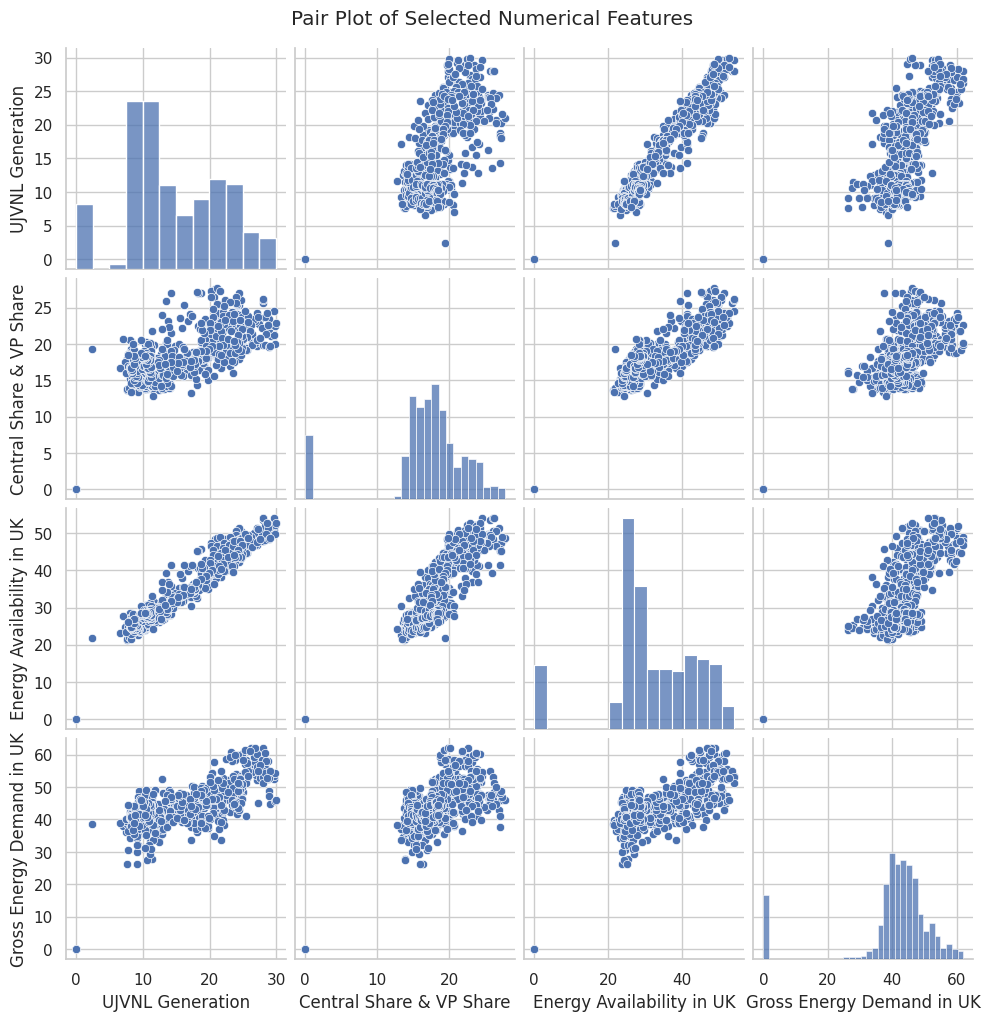

In [ ]:
# 1. Pair Plot (for first 4 numeric columns)
numeric_cols = pdf.select_dtypes(include=['float64', 'int64']).columns.tolist()
sns.pairplot(pdf[numeric_cols[:4]].dropna())
plt.suptitle("Pair Plot of Selected Numerical Features", y=1.02)
plt.show()

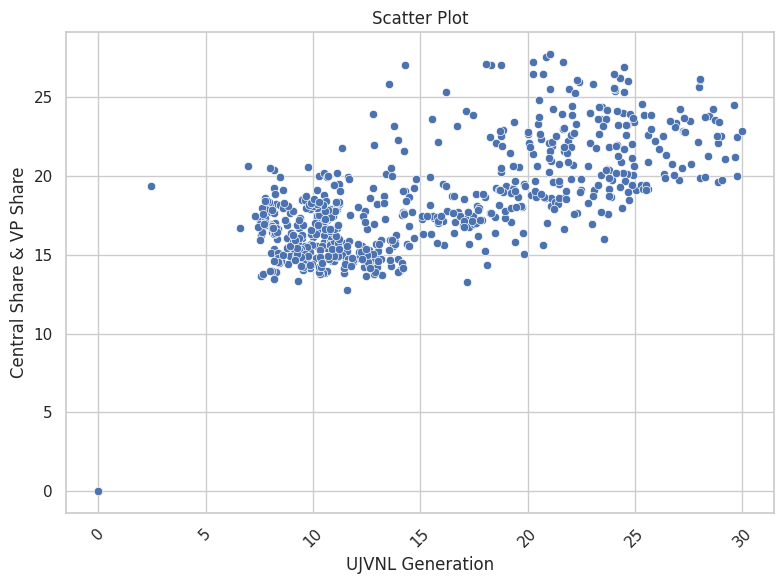

In [ ]:
# 2. Scatter Plot (example: Energy Availability vs Energy Shortage)
numeric_cols = pdf.select_dtypes(include=np.number).columns
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pdf, x=numeric_cols[0], y=numeric_cols[1])  # Use numeric columns
plt.title("Scatter Plot")
plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[1])
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout
plt.show()

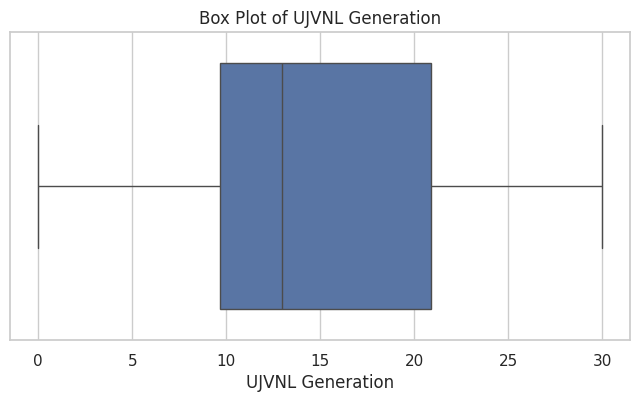

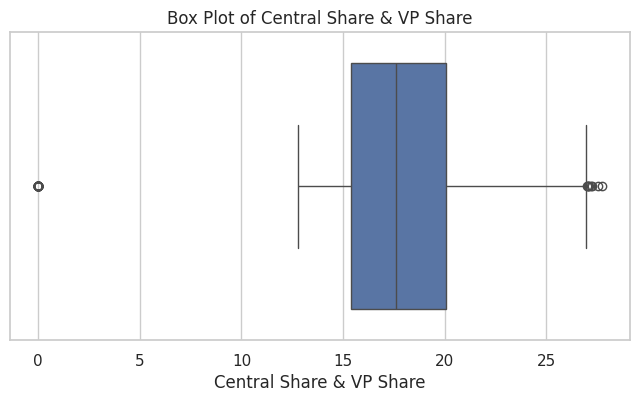

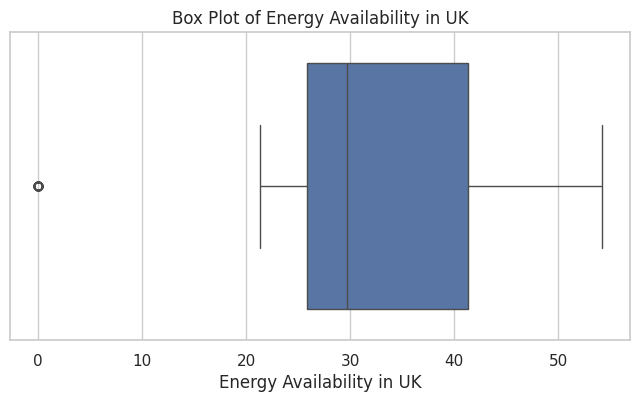

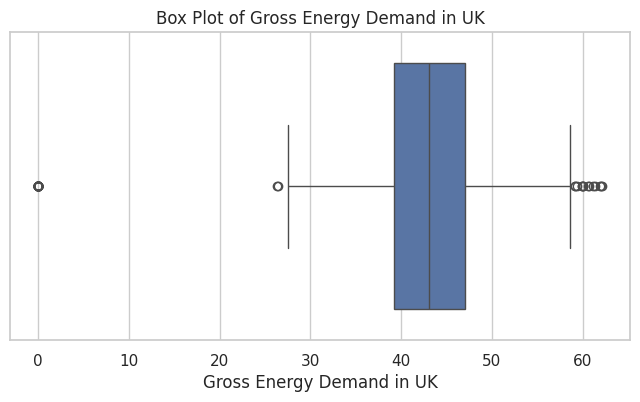

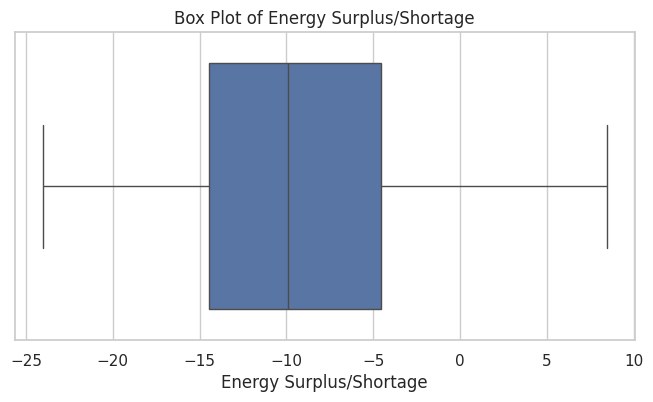

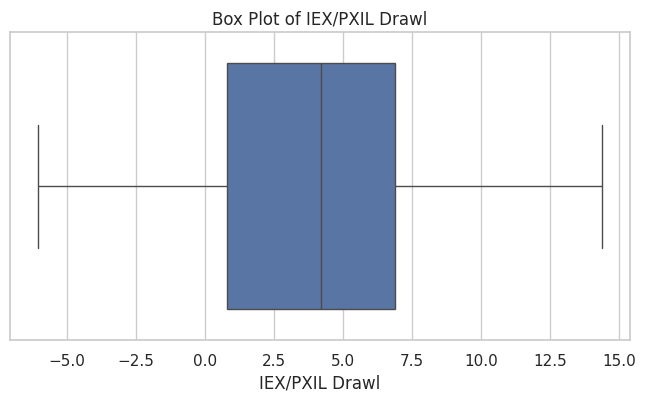

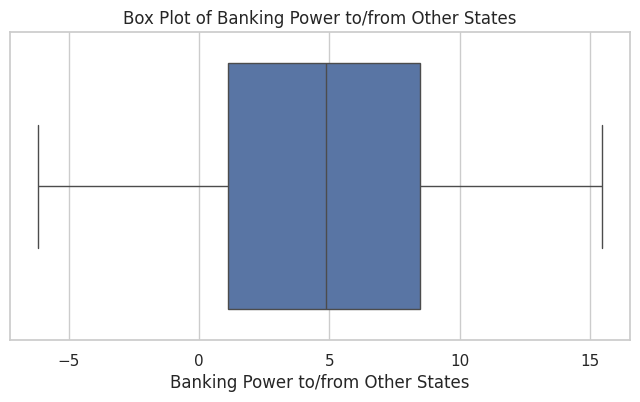

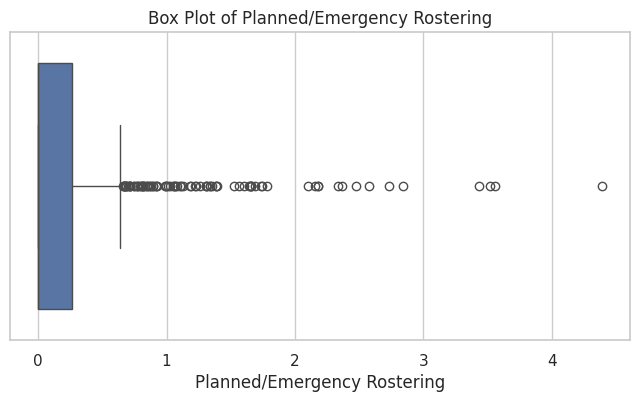

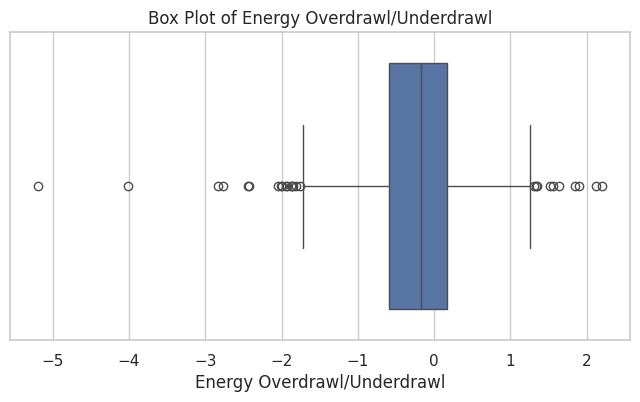

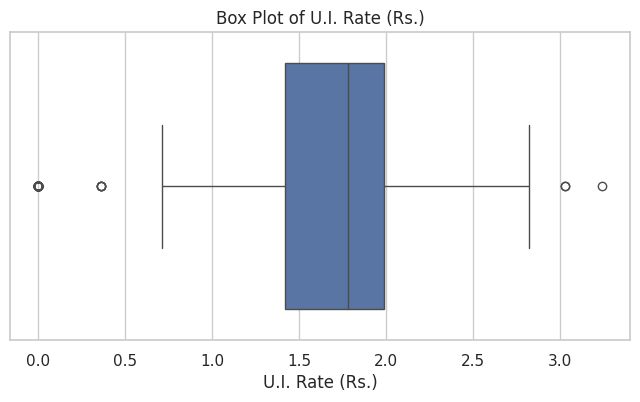

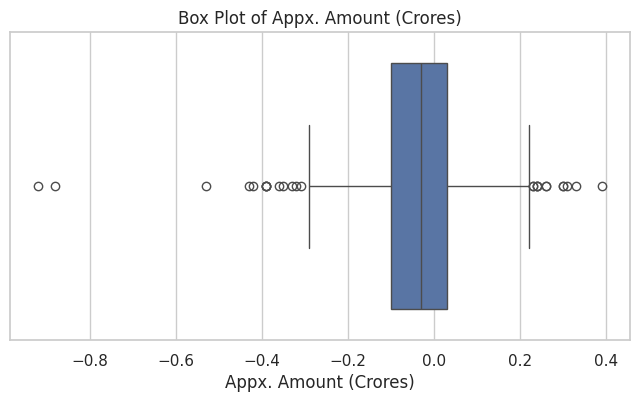

In [ ]:
# 3. Box Plot (for outlier detection)
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=pdf[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

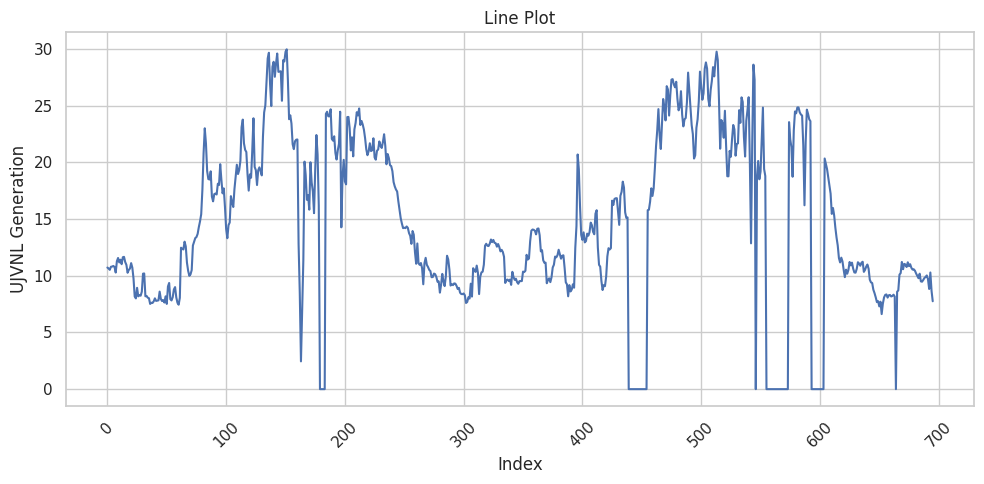

In [ ]:
# 4. Line Plot (e.g., Time series of energy shortage)
plt.figure(figsize=(10, 5))
sns.lineplot(data=pdf, x=pdf.index, y=numeric_cols[0])  # Use a numeric column
plt.title("Line Plot")
plt.xlabel("Index")
plt.ylabel(numeric_cols[0])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

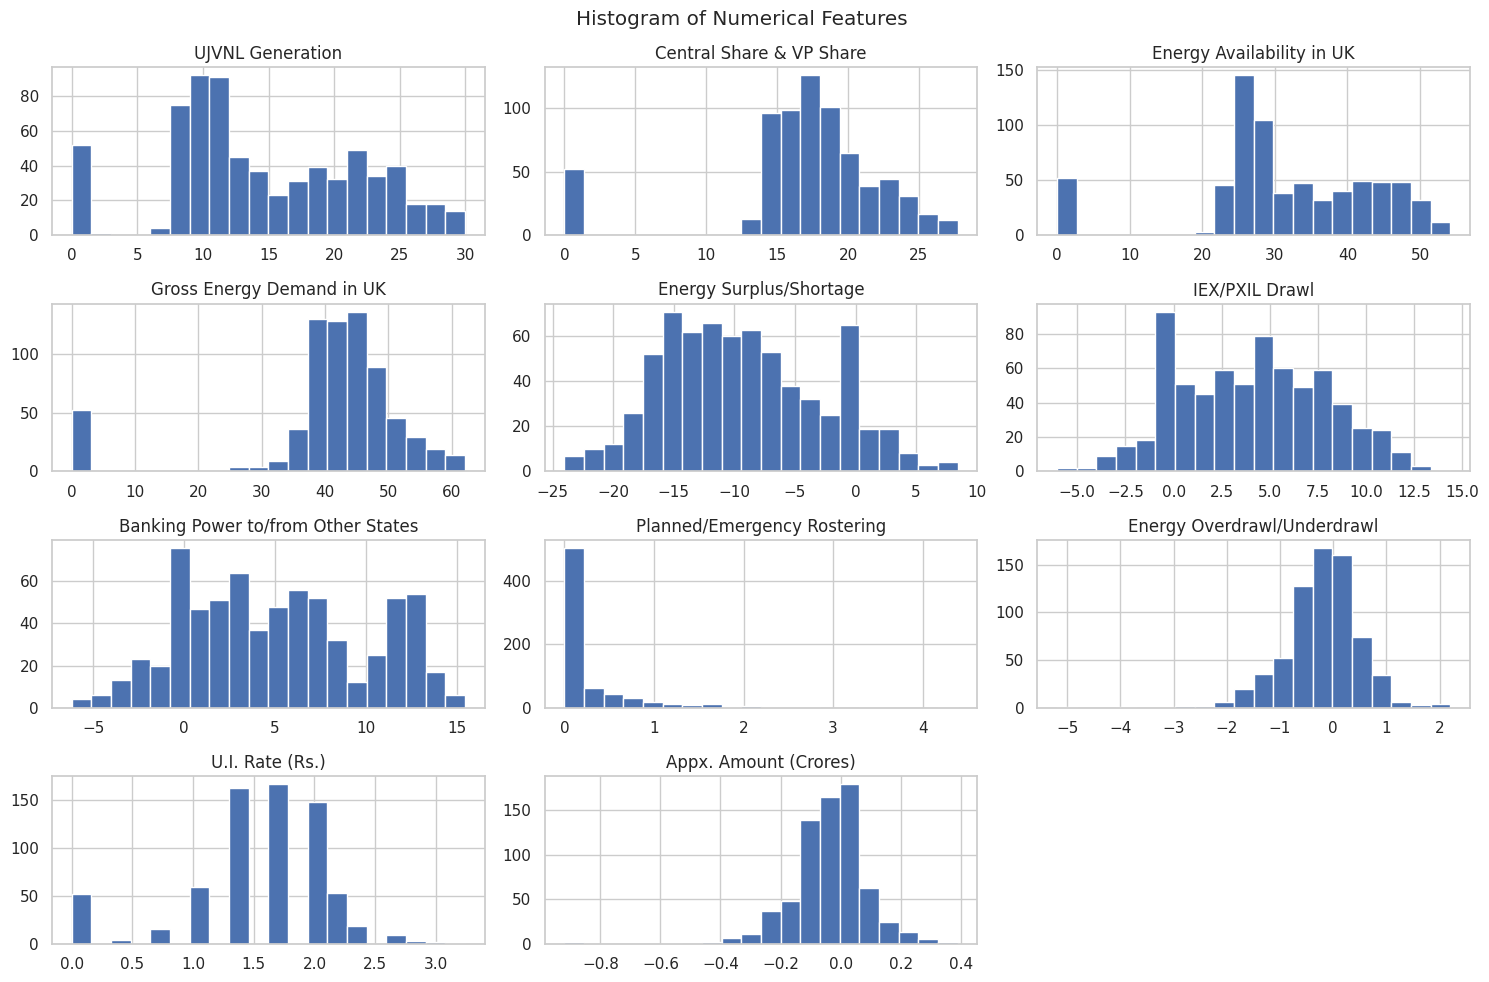

In [ ]:
# 5. Histogram (distribution of numerical features)
pdf.hist(figsize=(15, 10), bins=20)
plt.suptitle("Histogram of Numerical Features")
plt.tight_layout()
plt.show()

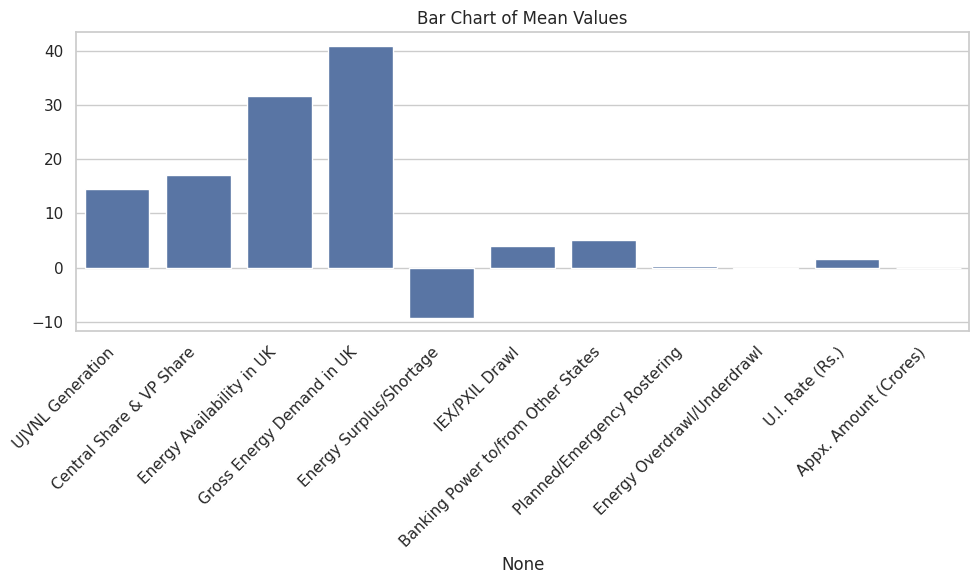

In [ ]:
# 6. Bar Chart (e.g., Monthly Average Energy Shortage)
plt.figure(figsize=(10, 6))
pdf_mean = pdf.select_dtypes(include=np.number).mean()  # Include only numeric types
sns.barplot(x=pdf_mean.index, y=pdf_mean.values)
plt.xticks(rotation=45, ha="right")  # Rotate & align labels
plt.title("Bar Chart of Mean Values")
plt.tight_layout()
plt.show()

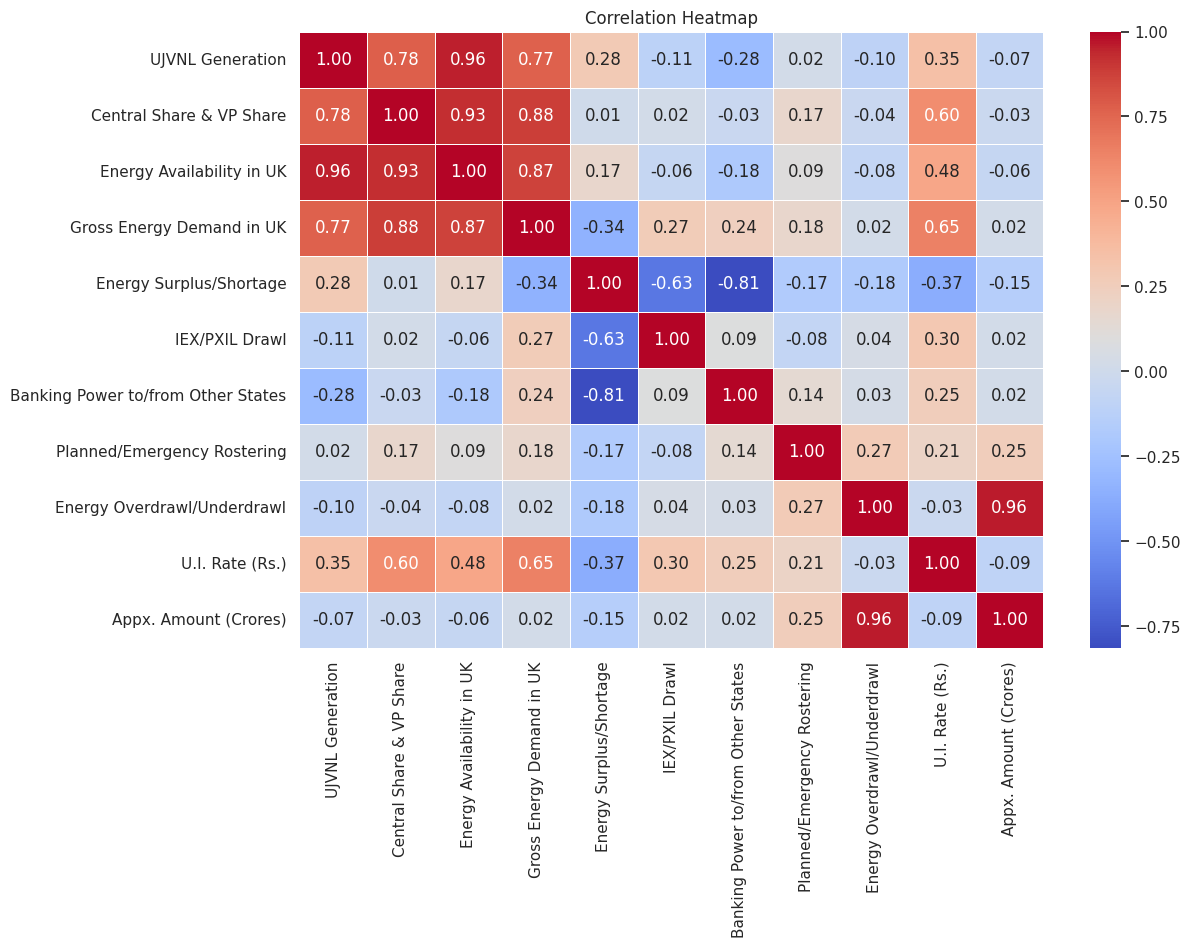

In [ ]:
# 7. Heatmap (Correlation matrix)
plt.figure(figsize=(12, 8))
corr_matrix = pdf.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# **4. Feature Engineering**:

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lag, month, dayofweek, to_date, regexp_replace
from pyspark.sql.window import Window
from pyspark.ml.feature import MinMaxScaler, VectorAssembler
from pyspark.ml.stat import Correlation

In [ ]:
# Initialize Spark session
spark = SparkSession.builder.appName("EnergyDataProcessing").getOrCreate()

In [ ]:
# Load the dataset
file_path = "Energy Dataset.csv"  # Update with the correct path
df = spark.read.csv(file_path, header=True, inferSchema=True)

In [ ]:
# Debug: Print schema to check column types
df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- UJVNL Generation: double (nullable = true)
 |-- Central Share & VP Share: double (nullable = true)
 |-- Energy Availability in UK: double (nullable = true)
 |-- Gross Energy Demand in UK: double (nullable = true)
 |-- Energy Surplus/Shortage: double (nullable = true)
 |-- IEX/PXIL Drawl: double (nullable = true)
 |-- Banking Power to/from Other States: double (nullable = true)
 |-- Planned/Emergency Rostering: double (nullable = true)
 |-- Energy Overdrawl/Underdrawl: double (nullable = true)
 |-- U.I. Rate (Rs.): double (nullable = true)
 |-- Appx. Amount (Crores): double (nullable = true)



In [ ]:
# Ensure 'date' is in proper DateType format
# Assuming 'date' column exists, change to 'Date' if necessary
df = df.withColumn("date", to_date(col("Date"), "dd-MMM-yy"))  # Adjust format if needed

In [ ]:
# Debug: Show first few rows to verify data
df.show(5)

+----------+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|      date|UJVNL Generation|Central Share & VP Share|Energy Availability in UK|Gross Energy Demand in UK|Energy Surplus/Shortage|IEX/PXIL Drawl|Banking Power to/from Other States|Planned/Emergency Rostering|Energy Overdrawl/Underdrawl|U.I. Rate (Rs.)|Appx. Amount (Crores)|
+----------+----------------+------------------------+-------------------------+-------------------------+-----------------------+--------------+----------------------------------+---------------------------+---------------------------+---------------+---------------------+
|2023-01-01|          10.725|                  14.859|                   25.584|                    41.26|                -15.676|         4.054|                            11

In [ ]:
# Ensure no missing values in key columns and the column to be scaled
# Replace 'Energy_consumption' with the correct column name
# For example, if it's 'Gross Energy Demand in UK':
df = df.dropna(subset=["Date", "Gross Energy Demand in UK"])

In [ ]:
# 1. Create lag-based features (Fix: Order by date in ascending order)
window_spec = Window.orderBy(col("date").asc())
# Replace 'energy_consumption' with 'Gross Energy Demand in UK'
df = df.withColumn("lag_1", lag("Gross Energy Demand in UK", 1).over(window_spec))
df = df.withColumn("lag_2", lag("Gross Energy Demand in UK", 2).over(window_spec))

In [ ]:
# 2. Extract date-related features
df = df.withColumn("month", month(col("date")))
df = df.withColumn("day_of_week", dayofweek(col("date")))

In [ ]:
# 3. Normalize/scale numerical features
num_cols = ["Gross Energy Demand in UK", "lag_1", "lag_2"]
# ----> Check if the column 'Gross Energy Demand in UK' has valid numeric values
# ----> and handle potential issues before scaling
df.select("Gross Energy Demand in UK").summary().show()  # Check statistics

# Clean the 'Gross Energy Demand in UK' column to remove commas and cast to double
df = df.withColumn("Gross Energy Demand in UK", regexp_replace(col("Gross Energy Demand in UK"), ",", "").cast("double"))

assembler = VectorAssembler(inputCols=["Gross Energy Demand in UK"], outputCol="energy_vec")
df_vec = assembler.transform(df)

scaler = MinMaxScaler(inputCol="energy_vec", outputCol="energy_scaled")
scaler_model = scaler.fit(df_vec)  # Now this should work
df_scaled = scaler_model.transform(df_vec)

+-------+-------------------------+
|summary|Gross Energy Demand in UK|
+-------+-------------------------+
|  count|                      695|
|   mean|        40.91925179856116|
| stddev|       13.016453360898602|
|    min|                      0.0|
|    25%|                   39.187|
|    50%|                   43.053|
|    75%|                   47.065|
|    max|                   62.116|
+-------+-------------------------+



In [ ]:
# 4. Identify important features using correlation
feature_cols = ["Gross Energy Demand in UK", "lag_1", "lag_2"]
# ----> Handle nulls before assembling the feature vector
df_scaled = df_scaled.dropna(subset=feature_cols)  # Drop rows with nulls in feature columns

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_features = assembler.transform(df_scaled).select("features")

correlation_matrix = Correlation.corr(df_features, "features").head()[0]
print("Correlation Matrix:\n", correlation_matrix.toArray())

Correlation Matrix:
 [[1.         0.87278784 0.78601194]
 [0.87278784 1.         0.87277278]
 [0.78601194 0.87277278 1.        ]]


In [ ]:
# Show final DataFrame
# ----> Replace 'energy_consumption' with 'Gross Energy Demand in UK'
df_scaled.select("date", "Gross Energy Demand in UK", "lag_1", "lag_2", "month", "day_of_week", "energy_scaled").show()

+----------+-------------------------+------+------+-----+-----------+--------------------+
|      date|Gross Energy Demand in UK| lag_1| lag_2|month|day_of_week|       energy_scaled|
+----------+-------------------------+------+------+-----+-----------+--------------------+
|2023-01-03|                   44.571|42.322| 41.26|    1|          3|[0.7175445939854466]|
|2023-01-04|                   45.678|44.571|42.322|    1|          4|[0.7353660892523666]|
|2023-01-05|                   46.701|45.678|44.571|    1|          5|[0.7518352759353468]|
|2023-01-06|                     47.3|46.701|45.678|    1|          6|[0.7614785240517741]|
|2023-01-07|                   45.927|  47.3|46.701|    1|          7| [0.739374718269045]|
|2023-01-08|                   43.935|45.927|  47.3|    1|          1|[0.7073056861356173]|
|2023-01-09|                   44.943|43.935|45.927|    1|          2|[0.7235333891428939]|
|2023-01-10|                   45.057|44.943|43.935|    1|          3|[0.7253686

# **5. Model Training & Testing**:

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [ ]:
# Initialize Spark session
spark = SparkSession.builder.appName("PySpark_ML_Training").getOrCreate()

In [ ]:
# Load dataset (Replace with your dataset path)
data_path = "/content/Energy Dataset.csv"
df = spark.read.csv(data_path, header=True, inferSchema=True)

In [ ]:
# Print dataset schema
df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- UJVNL Generation: double (nullable = true)
 |-- Central Share & VP Share: double (nullable = true)
 |-- Energy Availability in UK: double (nullable = true)
 |-- Gross Energy Demand in UK: double (nullable = true)
 |-- Energy Surplus/Shortage: double (nullable = true)
 |-- IEX/PXIL Drawl: double (nullable = true)
 |-- Banking Power to/from Other States: double (nullable = true)
 |-- Planned/Emergency Rostering: double (nullable = true)
 |-- Energy Overdrawl/Underdrawl: double (nullable = true)
 |-- U.I. Rate (Rs.): double (nullable = true)
 |-- Appx. Amount (Crores): double (nullable = true)



In [ ]:
# Identify feature and target columns
feature_columns = [col for col in df.columns if col not in ['Gross Energy Demand in UK', 'Date']]
target_column = 'Gross Energy Demand in UK'  # Use the actual target column name

In [ ]:
# Convert PySpark DataFrame to Pandas for scikit-learn processing
pandas_df = df.toPandas()

In [ ]:
# Handle missing values
pandas_df = pandas_df.dropna()

In [ ]:
# Convert categorical target to numeric if classification
if pandas_df[target_column].dtype == 'O':  # 'O' means object (categorical)
    pandas_df[target_column] = pandas_df[target_column].astype('category').cat.codes
    is_classification = True
else:
    is_classification = False

In [ ]:
# Split data into training and testing sets
X = pandas_df[feature_columns].values
y = pandas_df[target_column].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Select model based on target type
if is_classification:
    model = RandomForestClassifier(n_estimators=100, random_state=42)
else:
    model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
# Train the model
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the model
if is_classification:
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
else:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

RMSE: 1.0102
R² Score: 0.9890


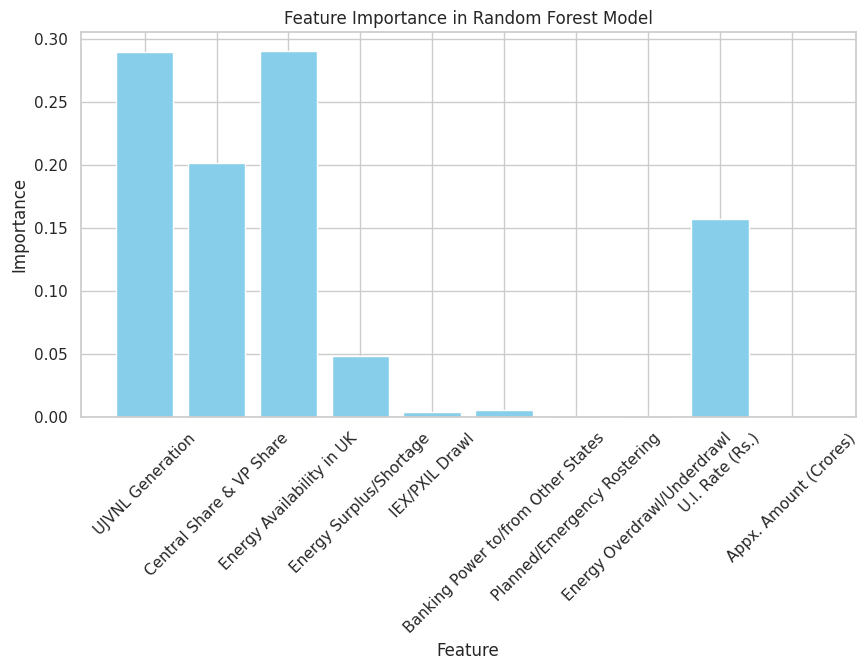

In [ ]:
# Feature Importance Plot
feature_importances = model.feature_importances_
plt.figure(figsize=(10, 5))
plt.bar(feature_columns, feature_importances, color='skyblue')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Hyperparameter tuning with Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(model, param_grid, cv=3, scoring='accuracy' if is_classification else 'neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: -2.1255918733470156


# **MODEL SAVE**:

In [ ]:
import joblib

# Assuming `model` is your trained RandomForestRegressor
model_save_path = "/content/random_forest_model.pkl"  # Update path if needed

# Save the model to disk using joblib
joblib.dump(model, model_save_path)

print(f"Model saved at: {model_save_path}")

Model saved at: /content/random_forest_model.pkl
